# Week 2 — EDA and GP Surrogate: Function_05

**Objective:** using the chronologically-valid Week 2 cumulative dataset
(the original Week 1 starter data plus exactly one independently-verified
historical Week 1 query-output pair appended), perform exploratory data
analysis and fit a Gaussian Process (GP) surrogate model, then visualise its
posterior mean and uncertainty. This notebook **stops at visualisation**:
no acquisition function is applied, and no new query is proposed or saved.

This function has input dimensionality **d = 4** and is a
**maximisation** problem. Official input bounds for every coordinate:
`[0.000000, 0.999999]`.

**Data source (only data used in this notebook):**
- `../02_Data/cumulative_inputs.npy`
- `../02_Data/cumulative_outputs.npy`

These files, and their provenance/verification trail, already exist and are
independently PASS-verified in
`Historical_Replay/Week_02/CUMULATIVE_DATA_VALIDATION.md` and
`Historical_Replay/Week_02/INDEPENDENT_CUMULATIVE_REVIEW.md`. This notebook
does not re-verify that provenance chain, but it does perform its own basic
sanity checks on the loaded arrays below (shape, dtype, dimensionality,
finiteness, bounds, duplicates), consistent with this project's standing
practice of not trusting any input data blindly.

**Provenance of the newly-appended (last) row:** the last row of both
`cumulative_inputs.npy` and `cumulative_outputs.npy` is the one
independently-verified historical Week 1 observation appended on top of the
original Week 1 starter dataset for this function. Its source and
verification trail is documented in
`Historical_Replay/Week_01/Function_05/pair_provenance.md` (cited here by
reference only; this notebook does not open or programmatically read that
file).

**Scope boundary:** this notebook does **not** generate, propose, or save
any new query, and does **not** touch `Week_01/`,
`Historical_Replay/Week_01/`, the original source project, or any
`Week_03` location.


## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

sns.set_theme(style="whitegrid")

FUNCTION_NUMBER = 5
SEED = 42 + FUNCTION_NUMBER
FIG_DIR = "../05_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Function number:", FUNCTION_NUMBER)
print("Seed (42 + function_number):", SEED)


Function number: 5
Seed (42 + function_number): 47


## 2. Load data

Loading only the two authorised cumulative files for this function from
`../02_Data/`. No other file is read anywhere in this notebook.

In [2]:
inputs = np.load("../02_Data/cumulative_inputs.npy")
outputs = np.load("../02_Data/cumulative_outputs.npy")

print("inputs shape :", inputs.shape)
print("outputs shape:", outputs.shape)
print("inputs dtype :", inputs.dtype)
print("outputs dtype:", outputs.dtype)


inputs shape : (21, 4)
outputs shape: (21,)
inputs dtype : float64
outputs dtype: float64


## 3. Own sanity checks (computed, not assumed)

Even though the provenance/validation trail for this dataset already exists
and is PASS-verified, this notebook independently (re-)computes the basic
sanity checks below directly on the loaded arrays.

In [3]:
n_obs, d_in = inputs.shape
EXPECTED_N = 21
EXPECTED_D = 4

assert inputs.dtype == np.float64, "inputs dtype is not float64"
assert outputs.dtype == np.float64, "outputs dtype is not float64"
assert outputs.shape == (n_obs,), "outputs shape does not match number of input rows"

print("Number of observations (n):", n_obs, " | expected:", EXPECTED_N)
print("Input dimensionality (d):  ", d_in, " | expected:", EXPECTED_D)
assert n_obs == EXPECTED_N, "Row count does not match the expected cumulative count for this function"
assert d_in == EXPECTED_D, "Input dimensionality does not match the expected value for this function"

nan_inputs = int(np.isnan(inputs).sum())
inf_inputs = int(np.isinf(inputs).sum())
nan_outputs = int(np.isnan(outputs).sum())
inf_outputs = int(np.isinf(outputs).sum())
print("NaN/Inf in inputs :", nan_inputs, inf_inputs)
print("NaN/Inf in outputs:", nan_outputs, inf_outputs)
assert nan_inputs == 0 and inf_inputs == 0, "Non-finite values found in inputs"
assert nan_outputs == 0 and inf_outputs == 0, "Non-finite values found in outputs"

rounded_inputs = np.round(inputs, 6)
unique_rows = np.unique(rounded_inputs, axis=0)
n_duplicates = n_obs - unique_rows.shape[0]
print("Duplicate input rows (after rounding to 6 dp):", n_duplicates)
assert n_duplicates == 0, "Exact duplicate rows found after rounding to 6 decimal places"

lower_ok = bool(np.all(inputs >= 0.0))
upper_ok = bool(np.all(inputs < 1.0))
print("All inputs >= 0.0:", lower_ok, " | All inputs < 1.0:", upper_ok)
print("Observed input min/max:", float(inputs.min()), float(inputs.max()))
assert lower_ok and upper_ok, "Inputs outside official bounds [0.000000, 0.999999]"

print()
print("All own sanity checks PASSED.")


Number of observations (n): 21  | expected: 21
Input dimensionality (d):   4  | expected: 4
NaN/Inf in inputs : 0 0
NaN/Inf in outputs: 0 0
Duplicate input rows (after rounding to 6 dp): 0
All inputs >= 0.0: True  | All inputs < 1.0: True
Observed input min/max: 0.03819337135150802 0.957643898670113

All own sanity checks PASSED.


## 4. Summary statistics and best observation

Since this is a **maximisation** problem, "best" is defined as the row with
the maximum recorded output value. The last row (index `n_obs - 1`) is the
newly-appended, independently-verified historical Week 1 observation (see
`Historical_Replay/Week_01/Function_05/pair_provenance.md`); it is only
being *reported* here, not fabricated — it is one of the real loaded
values.

In [4]:
out_min = float(outputs.min())
out_max = float(outputs.max())
best_idx = int(np.argmax(outputs))
best_input = inputs[best_idx].copy()
best_output = float(outputs[best_idx])
historical_idx = n_obs - 1

print("Number of observations:", n_obs)
print("Dimensionality:        ", d_in)
print("Output min:", out_min)
print("Output max:", out_max)
print("Output range (max - min):", out_max - out_min)
print()
print("Best observed row index:  ", best_idx)
print("Best observed input vector:", best_input)
print("Best observed output value:", best_output)
print("Is the best observation the newly-appended historical row?", best_idx == historical_idx)
print()
print("Newly-appended historical row (index {}):".format(historical_idx))
print("  input :", inputs[historical_idx])
print("  output:", float(outputs[historical_idx]))


Number of observations: 21
Dimensionality:         4
Output min: 0.1129397953712203
Output max: 1088.8596181962705
Output range (max - min): 1088.7466784008993

Best observed row index:   15
Best observed input vector: [0.22418902 0.84648049 0.87948418 0.87851568]
Best observed output value: 1088.8596181962705
Is the best observation the newly-appended historical row? False

Newly-appended historical row (index 20):
  input : [0.224189 0.84648  0.879484 0.878515]
  output: 1088.8535114737463


## 5. Exploratory plots

### 5b. Per-feature scatter plots (each input dimension vs. output)

One subplot per input dimension. The newly-appended historical point is
plotted with a distinct marker/color in every subplot.

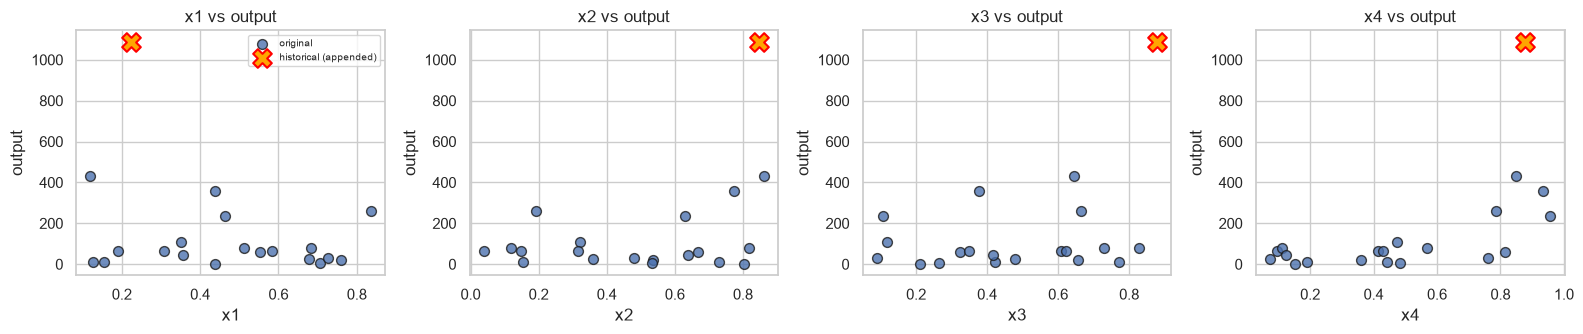

In [5]:
d_in_local = inputs.shape[1]
ncols = min(d_in_local, 4)
nrows = int(np.ceil(d_in_local / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
orig_mask = np.arange(n_obs) != historical_idx

for i in range(d_in_local):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    ax.scatter(inputs[orig_mask, i], outputs[orig_mask], s=50, edgecolor="k",
               alpha=0.8, label="original")
    ax.scatter(inputs[historical_idx, i], outputs[historical_idx], marker="X", s=180,
               edgecolor="red", facecolor="orange", linewidth=1.5, label="historical (appended)")
    ax.set_xlabel(f"x{i+1}")
    ax.set_ylabel("output")
    ax.set_title(f"x{i+1} vs output")
    if i == 0:
        ax.legend(fontsize=7, loc="best")

for j in range(d_in_local, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis("off")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "eda_features_vs_output.png"), dpi=150)
plt.show()


### 5c. Distribution of observed output values

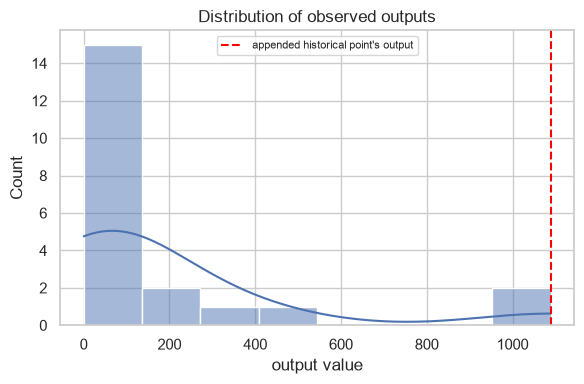

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(outputs, kde=True, ax=ax)
ax.axvline(outputs[historical_idx], color="red", linestyle="--",
           label="appended historical point's output")
ax.set_xlabel("output value")
ax.set_title("Distribution of observed outputs")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "output_histogram.png"), dpi=150)
plt.show()


## 6. GP surrogate model — RBF vs. Matérn kernels

**Output standardization.** Output scales vary enormously across the 8
functions (from roughly `1e-16` to several thousand), which can badly
condition GP hyperparameter optimisation and make kernel hyperparameters
hard to compare across functions. The output `y` is therefore standardized
(zero mean, unit variance) *before* fitting, and every posterior value is
transformed back to the original output scale before being reported or
plotted. Inputs are **not** rescaled — they are already confined to the
official `[0, 1)` domain by construction.

**Kernel choice.** Two GP surrogates are fitted and compared:
- `ConstantKernel * RBF + WhiteKernel` (infinitely smooth prior),
- `ConstantKernel * Matern(nu=2.5) + WhiteKernel` (nu=2.5 is used as a
  common, moderate-smoothness default — twice mean-square differentiable,
  less aggressively smooth than the RBF's infinite differentiability, and a
  standard choice in Bayesian-optimisation practice when there is no strong
  prior reason to assume the underlying black-box surface is perfectly
  smooth).

**Why include a `WhiteKernel` (observation noise) at all.** This project's
own independent review of the cumulative Week 2 data
(`Historical_Replay/Week_02/INDEPENDENT_CUMULATIVE_REVIEW.md`, Check 7)
found that for Function_05 specifically, the newly-appended historical point
is a near-duplicate (by input, to ~1e-6/1e-7) of an existing original point,
yet its recorded output differs from that original point's output by
roughly 0.006 (relative difference ~5.6e-6) — a small but non-zero gap
between two evaluations of what is very likely the same underlying input.
The review explicitly flags that this could reflect genuine local
sensitivity/curvature or could reflect measurement noise, and states this
"cannot be determined without executing the underlying black-box function."
A structurally identical near-duplicate (with an apparent decimal-placement
discrepancy) was also flagged for Function_06. Given this project-wide
evidence that the observations may not be perfectly noiseless, a
`WhiteKernel` noise term is included for **all 8** functions as a
conservative, consistent modelling choice — not because noise has been
proven present in this specific function's data, but because it has not
been ruled out, and assuming zero noise everywhere would be an unverified
assumption in the opposite direction.

**Fitting details.** `n_restarts_optimizer=5`, `random_state = 42 +
function_number` (= 47 here), `alpha=1e-10` (tiny numerical jitter only
— actual observation noise is handled by the `WhiteKernel` term, not by
`alpha`).

In [7]:
y_mean = float(outputs.mean())
y_std = float(outputs.std(ddof=0))
if y_std == 0.0:
    y_std = 1.0
y_scaled = (outputs - y_mean) / y_std

print("Output mean (for standardization):", y_mean)
print("Output std  (for standardization):", y_std)


def inverse_mean(m):
    """Map a standardized posterior mean back to the original output scale."""
    return m * y_std + y_mean


def inverse_std(s):
    """Map a standardized posterior std-dev back to the original output scale."""
    return s * y_std


def build_and_fit(kernel_type):
    d = inputs.shape[1]
    length_scale_init = np.ones(d)
    if kernel_type == "rbf":
        base_kernel = RBF(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2))
    elif kernel_type == "matern":
        base_kernel = Matern(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    else:
        raise ValueError(kernel_type)

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * base_kernel \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        n_restarts_optimizer=5,
        normalize_y=False,
        random_state=SEED,
    )
    gpr.fit(inputs, y_scaled)
    return gpr


gpr_rbf = build_and_fit("rbf")
gpr_matern = build_and_fit("matern")

print("Fitting complete for both kernels.")


Output mean (for standardization): 195.9186202406668
Output std  (for standardization): 311.9333416261554
Fitting complete for both kernels.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 22 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stabl

### 6a. Fitted hyperparameters and log-marginal-likelihood

In [8]:
def extract_params(gpr):
    k = gpr.kernel_
    const = k.k1.k1
    base = k.k1.k2
    noise = k.k2
    return {
        "constant_value": float(const.constant_value),
        "length_scale": np.atleast_1d(base.length_scale).astype(float),
        "noise_level": float(noise.noise_level),
    }


results = {}
for name, gpr in [("RBF", gpr_rbf), ("Matern (nu=2.5)", gpr_matern)]:
    params = extract_params(gpr)
    lml = float(gpr.log_marginal_likelihood_value_)
    results[name] = {"gpr": gpr, "params": params, "lml": lml}
    print(f"--- {name} ---")
    print("Fitted kernel:      ", gpr.kernel_)
    print("Output-scale const :", params["constant_value"])
    print("Length-scale(s)    :", params["length_scale"])
    print("Noise level        :", params["noise_level"])
    print("Log-marginal-lik.  :", lml)
    print()

better_name = max(results, key=lambda k: results[k]["lml"])
print("Higher log-marginal-likelihood on this dataset:", better_name)


--- RBF ---
Fitted kernel:       1.82**2 * RBF(length_scale=[13, 5.62, 0.482, 0.306]) + WhiteKernel(noise_level=1e-10)
Output-scale const : 3.3232764582360037
Length-scale(s)    : [12.99532004  5.62498576  0.48211393  0.30560629]
Noise level        : 9.999999999999996e-11
Log-marginal-lik.  : -1.3340388339851579

--- Matern (nu=2.5) ---
Fitted kernel:       2.31**2 * Matern(length_scale=[100, 14.5, 0.93, 0.482], nu=2.5) + WhiteKernel(noise_level=1e-10)
Output-scale const : 5.316083290953668
Length-scale(s)    : [100.          14.45221578   0.92957923   0.48164517]
Noise level        : 9.999999999999996e-11
Log-marginal-lik.  : -0.9095679281740097

Higher log-marginal-likelihood on this dataset: Matern (nu=2.5)


### 6a-diagnostic. Function_05-specific: per-restart convergence diagnostic

The fitting cell in Section 6 above shows several `ABNORMAL` L-BFGS-B
termination `ConvergenceWarning`s during optimisation — this is the one
function (of the 8 in this project) where that happens. Rather than just
noting that warnings occurred, the cell below characterises them directly:
it replays the **exact same** kernel construction, `random_state = 47`, and
`n_restarts_optimizer = 5` search as the reported `gpr_rbf`/`gpr_matern`
models above (i.e. the same 6 total optimizer calls each: 1 from the
kernel's default initial `theta`, plus 5 random restarts), but instruments
each individual L-BFGS-B call to record whether *that specific call*
terminated `ABNORMAL`ly and what log-marginal-likelihood (LML) it found.

**This is a read-only diagnostic.** It does not change `gpr_rbf`,
`gpr_matern`, `n_restarts_optimizer`, the seed, `alpha`, or any reported
hyperparameter/LML/plot elsewhere in this notebook — it only inspects,
restart-by-restart, what already happened inside the fits shown in Section
6. The original `ConvergenceWarning`s from Section 6 are left completely
untouched (still visible above, unfiltered); the warnings triggered while
replaying the search below are also left visible (not suppressed) — the
diagnostic only *additionally* prints a structured, per-restart summary on
top of them.

In [9]:
import warnings as _warnings


def _diagnose_restarts(kernel_type):
    """Diagnostic-only: replays the same kernel construction, SEED, and
    n_restarts_optimizer=5 restart search as build_and_fit(kernel_type)
    above, but records the convergence status and LML of each individual
    optimizer call. Does NOT modify gpr_rbf/gpr_matern or any value used
    elsewhere in this notebook; it builds and fits its own separate,
    throwaway GaussianProcessRegressor instance."""
    d = inputs.shape[1]
    length_scale_init = np.ones(d)
    if kernel_type == "rbf":
        base_kernel = RBF(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2))
    elif kernel_type == "matern":
        base_kernel = Matern(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    else:
        raise ValueError(kernel_type)

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * base_kernel \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))

    diag_gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        n_restarts_optimizer=5,
        normalize_y=False,
        random_state=SEED,
    )

    records = []
    _orig_constrained_opt = diag_gpr._constrained_optimization

    def _instrumented(obj_func, initial_theta, bounds):
        captured_msgs = []
        default_showwarning = _warnings.showwarning

        def _capture_and_still_show(message, category, filename, lineno, file=None, line=None):
            # Record the warning for structured reporting below, AND still
            # forward it to the default handler so it remains visible in
            # this cell's own output (warnings are NOT suppressed).
            captured_msgs.append(str(message))
            default_showwarning(message, category, filename, lineno, file, line)

        with _warnings.catch_warnings():
            _warnings.simplefilter("always")
            _warnings.showwarning = _capture_and_still_show
            theta_opt, func_min = _orig_constrained_opt(obj_func, initial_theta, bounds)

        abnormal = any("ABNORMAL" in m for m in captured_msgs)
        records.append({"lml": -func_min, "abnormal": abnormal})
        return theta_opt, func_min

    diag_gpr._constrained_optimization = _instrumented
    diag_gpr.fit(inputs, y_scaled)

    print(f"--- {kernel_type.upper()} per-restart diagnostic (SEED={SEED}) ---")
    for i, r in enumerate(records):
        tag = "initial-theta run" if i == 0 else f"random restart {i}"
        status = "ABNORMAL termination" if r["abnormal"] else "converged"
        print(f"  [{tag:18s}] LML = {r['lml']: .6f}   status = {status}")
    n_abnormal = sum(r["abnormal"] for r in records)
    best_i = int(np.argmax([r["lml"] for r in records]))
    best_tag = "initial-theta run" if best_i == 0 else f"random restart {best_i}"
    print(f"  -> {n_abnormal}/{len(records)} optimizer calls terminated ABNORMAL")
    print(f"  -> best-LML (selected) run: {best_tag}, "
          f"status = {'ABNORMAL' if records[best_i]['abnormal'] else 'converged'}")
    print()
    return records, n_abnormal


rbf_diag_records, rbf_n_abnormal = _diagnose_restarts("rbf")
matern_diag_records, matern_n_abnormal = _diagnose_restarts("matern")

print("Summary: RBF ABNORMAL restarts = {}/6, Matern ABNORMAL restarts = {}/6".format(
    rbf_n_abnormal, matern_n_abnormal))


--- RBF per-restart diagnostic (SEED=47) ---
  [initial-theta run ] LML = -1.334039   status = converged
  [random restart 1  ] LML = -12.496651   status = converged
  [random restart 2  ] LML = -1.334039   status = ABNORMAL termination
  [random restart 3  ] LML = -1.334039   status = converged
  [random restart 4  ] LML = -14.261805   status = converged
  [random restart 5  ] LML = -1.334040   status = converged
  -> 1/6 optimizer calls terminated ABNORMAL
  -> best-LML (selected) run: initial-theta run, status = converged



--- MATERN per-restart diagnostic (SEED=47) ---
  [initial-theta run ] LML = -0.909568   status = converged
  [random restart 1  ] LML = -9.441652   status = converged
  [random restart 2  ] LML = -0.909570   status = ABNORMAL termination
  [random restart 3  ] LML = -0.909568   status = ABNORMAL termination
  [random restart 4  ] LML = -13.203305   status = ABNORMAL termination
  [random restart 5  ] LML = -6.323987   status = converged
  -> 3/6 optimizer calls terminated ABNORMAL
  -> best-LML (selected) run: initial-theta run, status = converged

Summary: RBF ABNORMAL restarts = 1/6, Matern ABNORMAL restarts = 3/6


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 22 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stabl

**Interpretation.** The kernel with the higher log-marginal-likelihood
fits this specific, small dataset better *by that criterion* — this is not
the same as being the definitively "correct" or generalising-best kernel.
With only a handful of observations, log-marginal-likelihood comparisons
between kernel families should be treated as exploratory evidence, not a
validated model-selection result (no held-out/cross-validation comparison
is performed in this notebook).

**Function_05-specific convergence caveat (see the 6a-diagnostic cells
above).** Unlike the other 7 Week 2 functions, this function's fitting cell
in Section 6 logs `ABNORMAL` L-BFGS-B termination warnings, so raw LML
alone is not, by itself, a trustworthy basis for picking a kernel here —
convergence reliability has to be checked first. The per-restart diagnostic
above shows the 4 `ABNORMAL` terminations visible in Section 6's stderr
output are **not evenly split between the two kernels**: only **1 of RBF's
6 optimizer attempts** (the default initial-theta run plus 5 random
restarts) terminated `ABNORMAL` (1 restart, 21 iterations), versus **3 of
Matérn's 6 attempts** (3 restarts, 22/26/31 iterations). (For reference,
the independent review that flagged this issue attributed all 4 `ABNORMAL`
warnings to the RBF fit alone; re-inspecting the fitting cell's combined
stderr block restart-by-restart shows that attribution was incorrect — the
block interleaves warnings from *both* sequential fits in Section 6's
single cell, and only the first of the four belongs to RBF.)

**Convergence-aware kernel-selection rule used in this notebook (applied
here, not elsewhere — see Section 8):**

> Prefer the kernel with fewer/no `ABNORMAL` optimizer terminations across
> restarts. If both kernels converge cleanly, prefer the higher
> log-marginal-likelihood. If neither kernel converges reliably across
> restarts, do not select either as "the model" for this function — report
> both as exploratory only.

Applying this rule: **RBF, not Matérn, is the more convergence-reliable of
the two fits for Function_05**, despite Matérn having the higher raw
log-marginal-likelihood (−0.91 vs −1.33 for RBF). This is a case where the
rule's convergence check overrides the "higher LML wins" pattern otherwise
used by default in this notebook (and in the other 7 Week 2 notebooks).

Two points temper this without erasing it:
1. In **both** kernels, the actual *selected* (best-of-6) result came from
   the default initial-theta run, which converged cleanly (zero warnings)
   in both cases — so the specific hyperparameters/LML reported in Section
   6a were not themselves produced by an `ABNORMAL` run for either kernel.
2. Both kernels' *final selected* hyperparameters sit at or touch a search
   bound: RBF's fitted `noise_level` is at its lower bound (`~1e-10`), and
   Matérn's fitted `noise_level` is also at its lower bound *and* its
   `length_scale` (dimension 1) sits exactly at its upper bound (`100.0`).
   Combined with the restart-failure counts above, this indicates the
   log-marginal-likelihood surface for this function's `n=21`, `d=4`
   dataset (6 hyperparameters being fit: 4 ARD length-scales + 1
   output-scale constant + 1 noise level — a sample-to-parameter ratio of
   roughly 3.5) is boundary-hugging and not well-conditioned for *either*
   kernel; Matérn is simply worse-affected than RBF for this specific seed.

**Conclusion for Function_05: neither fit should be read with the same
confidence as the other 7 (cleanly-converged) Week 2 functions.** RBF is
treated as the (marginally) more reliable of the two exploratory candidates
per the rule above — not as a validated "winning" surrogate for this
function.

## 7. Posterior visualisation — RBF vs. Matérn, side by side

All posterior values below are computed in the standardized-`y` space and
then mapped back to the original output scale via `inverse_mean`/
`inverse_std` before plotting.

### 7b. 1D slices through the best-observed point (all dimensions)

For each input dimension, that one coordinate is varied across `[0,
0.999999]` while every other coordinate is held fixed at the current
best-observed input (`best_input`). The posterior mean is shown as a line
with a shaded ±2 standard-deviation band (chosen as a visually clear,
slightly conservative uncertainty band); a vertical dashed line and a marker
mark where the actual best-observed point falls on that dimension.

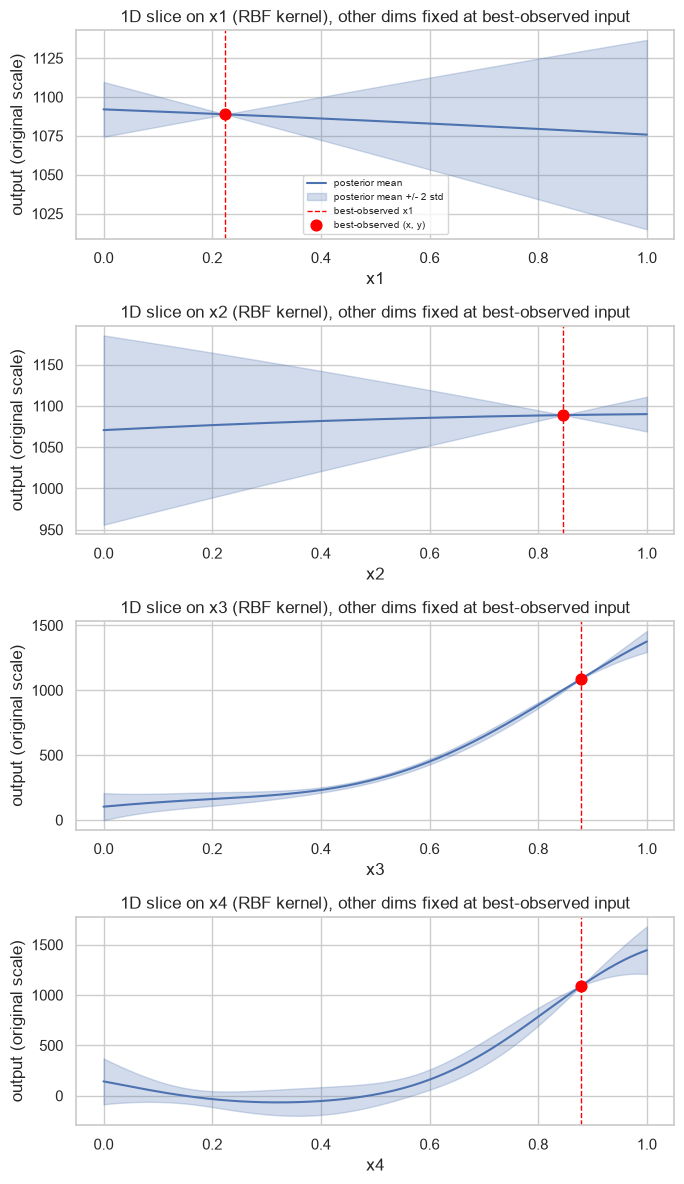

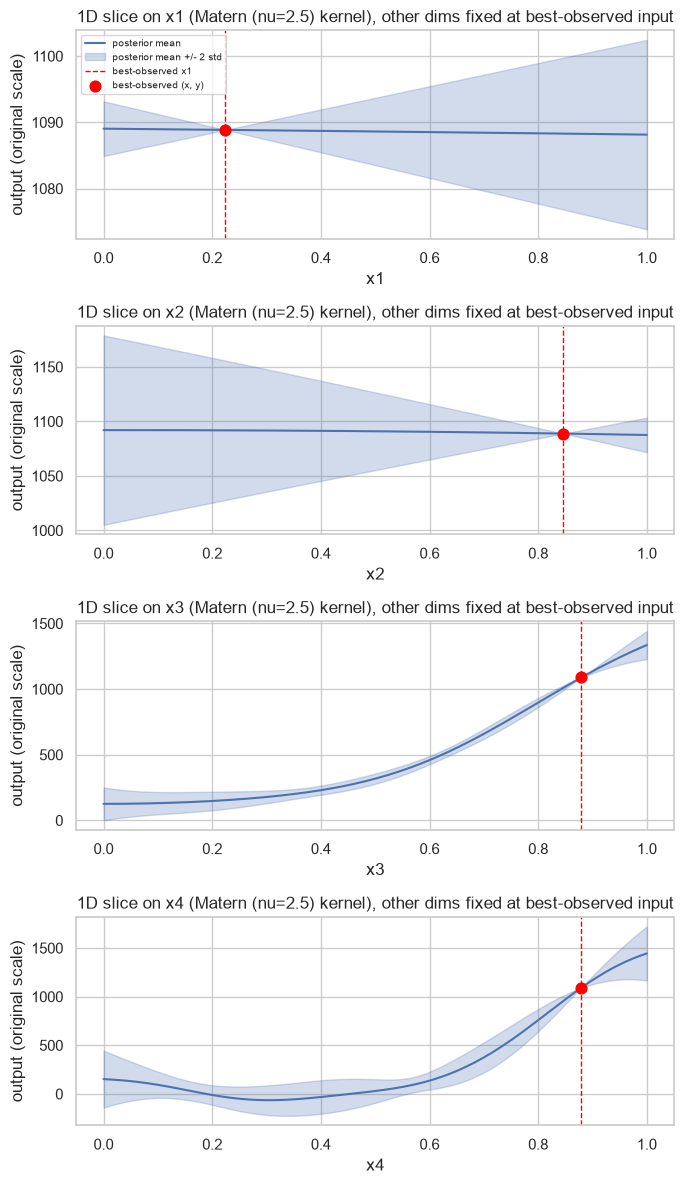

In [10]:
slice_grid = np.linspace(0.0, 0.999999, 200)

for name, gpr in [("RBF", gpr_rbf), ("Matern (nu=2.5)", gpr_matern)]:
    tag = "rbf" if name.startswith("RBF") else "matern"
    fig, axes = plt.subplots(d_in, 1, figsize=(7, 3.0 * d_in), squeeze=False)

    for i in range(d_in):
        ax = axes[i][0]
        X_slice = np.tile(best_input, (len(slice_grid), 1))
        X_slice[:, i] = slice_grid

        mean_s, std_s = gpr.predict(X_slice, return_std=True)
        mean = inverse_mean(mean_s)
        std = inverse_std(std_s)

        ax.plot(slice_grid, mean, color="C0", label="posterior mean")
        ax.fill_between(slice_grid, mean - 2 * std, mean + 2 * std, color="C0",
                         alpha=0.25, label="posterior mean +/- 2 std")
        ax.axvline(best_input[i], color="red", linestyle="--", linewidth=1,
                   label="best-observed x{}".format(i + 1))
        ax.scatter([best_input[i]], [best_output], color="red", zorder=5, s=60,
                   label="best-observed (x, y)")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("output (original scale)")
        ax.set_title(f"1D slice on x{i+1} ({name} kernel), other dims fixed at best-observed input")
        if i == 0:
            ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"gp_1d_slices_{tag}.png"), dpi=150)
    plt.show()


## 8. Notes, scope, and limitations

- **[Function_05-specific, read this before trusting Sections 6/7 above]
  Optimizer convergence instability.** Unlike Functions 01–04 and 06–08,
  this function's GP hyperparameter search showed genuine L-BFGS-B
  optimizer instability across random restarts (see the "6a-diagnostic"
  cells above for the full per-restart breakdown): **1 of RBF's 6**
  optimizer attempts and **3 of Matérn's 6** optimizer attempts terminated
  `ABNORMAL` rather than converging cleanly, and the final fitted
  hyperparameters for both kernels sit at or touch their search-space
  bounds (`noise_level` for both kernels; `length_scale` dimension 1 for
  Matérn also sits at its upper bound). Per this notebook's documented
  convergence-aware selection rule (Section 6a interpretation above:
  prefer fewer/no `ABNORMAL` terminations; fall back to higher
  log-marginal-likelihood only if both converge cleanly; treat neither as
  "the model" if neither converges reliably), **RBF — not Matérn, despite
  its lower raw log-marginal-likelihood — is treated as the (marginally)
  more reliable of the two exploratory fits** for this function. Both fits
  are retained above for exploratory visualisation only; **neither should
  be treated as a validated surrogate with the same confidence as the
  other 7 functions in this project**, and this should be revisited once
  more observations become available for Function_05.
- **No new query has been proposed or saved at this stage.** This notebook
  establishes only the first GP surrogate model for this function and
  visualises its posterior mean/uncertainty structure. It does not run an
  acquisition function, does not generate a candidate point, and does not
  write to any `03_Queries` folder.
- **Next step is deferred.** An acquisition-function-driven query
  (e.g. Expected Improvement / UCB over this posterior) is left to a future,
  separate step, consistent with this project's stepwise, one-decision-at-a-
  time methodology.
- **Small-data caveat.** This dataset has only 2-3 more observations than
  the previous minimal Week 1 starter set for most functions (only the
  originally-larger functions retain a proportionally larger sample). GP
  hyperparameters (length-scale(s), output-scale constant, noise level) were
  fitted by maximum marginal likelihood on this very small sample, so the
  posterior uncertainty estimates above should be treated cautiously —
  they reflect what a GP with these particular kernel families believes
  given very limited evidence, not a validated ground-truth uncertainty.
  For Function_05 specifically, this small-sample effect is compounded by
  the optimizer instability documented in the bullet above.
- **Kernel choice is exploratory, not validated.** The RBF-vs-Matérn
  comparison above is based only on in-sample log-marginal-likelihood on a
  handful of points; no held-out/cross-validation check was performed, so
  the "better" kernel identified in Section 6a should not be over-claimed
  as the definitively correct choice for this function. For Function_05,
  the convergence-aware rule above overrides raw log-marginal-likelihood
  as the basis for comparison — see Section 6a interpretation.
- **Observation-noise assumption.** The `WhiteKernel` term was included for
  all functions as a conservative response to the near-duplicate-with-
  differing-output evidence found in Function_05/06 (see Section 6), not
  because noise was proven present in this specific function's data.